# albireo end to end: a tour of the outputs

This notebook runs the example dataset packaged with albireo, which requires no download
and no network access, through the `Disentangler` façade and shows the output of each
stage: the derivations implied by the declaration, the MAP plus ML-II fit summary, the
disentangled spectra with their uncertainty band, the residual diagnostics, the NUTS
posterior over the orbit, spectra drawn from the joint posterior, and a sensitivity
forecast for epochs that have not yet been observed.

Background and references: [science overview](../science.md).

Install with the plotting extra:

```
pip install "albireo[plots]"
```

Two limitations are repeated in the package's own summaries:

- The continuum light fractions are assumed, not measured. With constant light the data
  constrain only the products `l_i * d_i`, so the fractions are an input the fit cannot
  contradict.
- Each component's smooth envelope is set by the prior rather than by the data (the
  `k = 0` degeneracy). The uncertainty band, not the posterior mean, indicates where the
  data constrain the spectrum.

The saved outputs and timings come from a single run on a 16-core desktop. Absolute times
differ between machines, and every first call includes JAX compilation. All steps are
seeded, so the numbers reproduce.

In [1]:
import time

import matplotlib
import numpy as np

import albireo as ab

matplotlib.rcParams["figure.dpi"] = 110

print(f"albireo {ab.__version__}")

dataset, truth = ab.load_example("sb2_sim", with_truth=True)
print(dataset.summary())
print(f"\ninjected truth: P = {truth['period']} d, e = {truth['ecc']}, K = {truth['k']} km/s")

albireo 0.1.0.dev0
Dataset: 12 epochs, frame='topocentric'
  BJD_TDB 0.00000 to 14.85000 (span 14.85000 d)
  instruments (1):
    DEMO  12 epochs, 4505.00-4554.98 A, 10008 px
  good pixels: 10008 / 10008 (100.0%)

injected truth: P = 6.0 d, e = 0.15, K = [42.0, 63.0] km/s


## Declare the system

The façade takes a declaration of the system (components, orbit priors, instrument LSF)
and derives the quantities the expert path requires as explicit arguments: the velocity
budget from the support of the priors, the grid margin, the conjunction phase (scanned
before any optimization), and the smoothness hyperparameters by ML-II. `explain()` prints
every derivation and `expert()` returns the corresponding `(model, priors, init)` triple.

In [2]:
light = truth["light_fractions"]  # assumed, not measured: only l_i * d_i is observable

dis = ab.Disentangler(
    dataset,
    components=[
        ab.Star("primary", light=float(light[0])),
        ab.Star("secondary", light=float(light[1])),
    ],
    orbit=ab.Orbit(
        period=ab.Between(5.5, 6.5),
        k=ab.Between([10.0, 10.0], [90.0, 90.0]),
        ecc=ab.Between(0.0, 0.64),
    ),
    lsf={"DEMO": 6.5},
    dv_kms=4.0,
)
print(dis.explain())

Disentangler: 2 star(s), 12 epochs, frame='topocentric'
  components (model row order): primary, secondary

velocity budget (km/s)
    sum of stellar |K| bounds             180.0
    x (1 + e_max = 1.64)                  295.2
    barycentric motion (both signs)        60.0
    x 1.05 slack                          373.0
    total                                 373.0

model grid   1037 px, 4498.74-4561.36 A, dv=4.000 km/s
  margin     373.0 km/s of shift + 6.50 km/s of LSF sigma
  operators  1 group(s), half-bandwidth 111
  (the bandwidth follows the budget, and the solve cost follows the bandwidth: narrowing the k or ecc priors is what makes a fit cheaper)

sampled sites: k, log_eta, log_tau, period, secosw, sesinw, t_conj

Assumed, not measured:
  light fractions    primary=0.62  secondary=0.38
      only l_i * d_i is observable, so every recovered depth scales as 1/l_i.
  smoothness starts  primary=300  secondary=300
      ML-II fits these, but which basin it finds depends on where

## Fit: MAP and ML-II in one call

The summary reports the optimizer's own diagnostics, the conjunction scan contrast, the
orbit, the ML-II smoothness table (with a flag on any hyperparameter the data did not
move), the residual z-score RMS (near 1 when the noise model describes the data) and the
assumptions block.

In [3]:
t0 = time.perf_counter()
fit = dis.fit()
print(f"[{time.perf_counter() - t0:.1f} s, including JAX compilation]\n")
print(fit.summary())

[37.8 s, including JAX compilation]



MAP fit: potential -28048.6, |grad| 0.00358, 181 steps (converged)
  conjunction scan: t_conj = 0.73171, 1.15e+05 nats between the best and worst phase

  period    6.000105 d
  ecc       0.1512    omega 0.6964 rad
  K(primary)    41.987 km/s   (light 0.62)
  K(secondary)    62.973 km/s   (light 0.38)

ML-II smoothness (empirical Bayes: fitted here, then frozen for sampling)
  primary        tau       300 ->       620 (+0.24 sigma)   eta        5 ->     10.3
  secondary      tau       300 ->  1.12e+03 (+0.44 sigma)   eta        5 ->     3.27

  residual z-score RMS 0.998

Assumed, not measured:
  light fractions    primary=0.62  secondary=0.38
      only l_i * d_i is observable, so every recovered depth scales as 1/l_i.
  smoothness starts  primary=300  secondary=300
      ML-II fits these, but which basin it finds depends on where tau starts.


## The disentangled spectra and their uncertainty band

The component spectra are recovered as deviations from a unit continuum, conditional on
the MAP orbit, with a pointwise uncertainty band. Where the epochs give little leverage
the band widens toward the prior, which records that the data do not constrain those
pixels. The model grid is wider than the data by a margin set by the velocity budget and
the LSF, derived by the façade above, so the band widens in the wings: those pixels are
prior-only.

The injected truth lies on the grid the example was generated on, so it is resampled onto
the model grid for the overlay. Its deviation is zero outside that window, as the
simulation put it there.

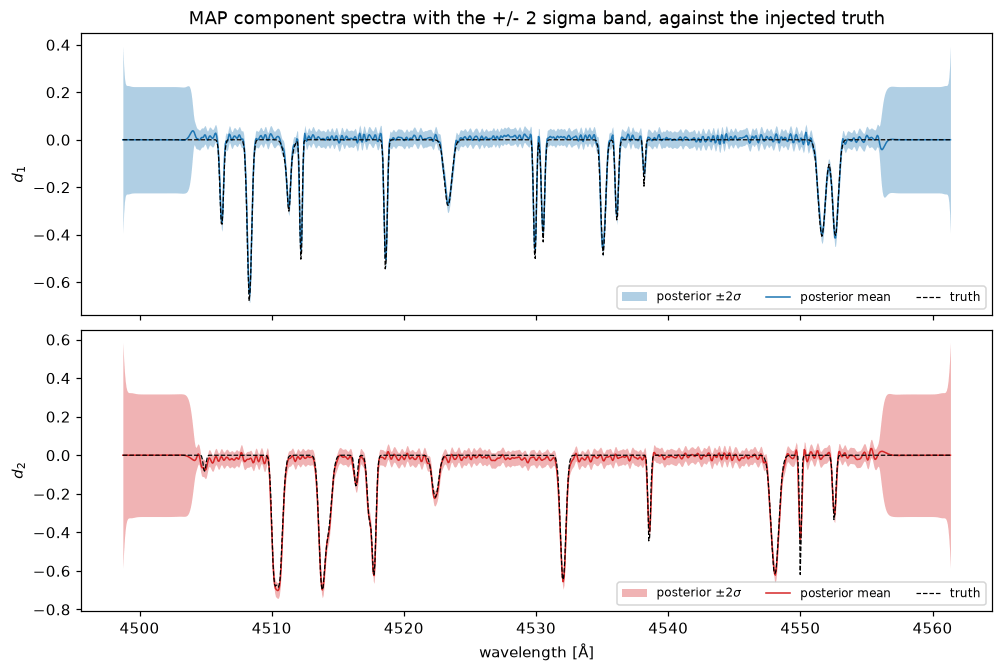

In [4]:
truth_grid = ab.LogGrid(x0=truth["grid_x0"], dx=truth["grid_dx"], n=int(truth["grid_n"]))
truth_on_model = np.stack(
    [
        np.interp(dis.grid.wave, truth_grid.wave, component, left=0.0, right=0.0)
        for component in truth["components"]
    ]
)

fig, axes = ab.plot_spectra(dis.grid, fit.spectra(), std=fit.std(), truth=truth_on_model)
axes[0].set_title("MAP component spectra with the +/- 2 sigma band, against the injected truth")
fig.set_layout_engine("constrained")

## Residual diagnostics

Whitened residuals in three views: their distribution against a unit normal, the
per-epoch RMS, and the lag-1 autocorrelation within each exposure. A z-RMS near 1 with
flat per-epoch structure passes the model check; phase-dependent structure would indicate
that the model is absorbing signal it should describe.

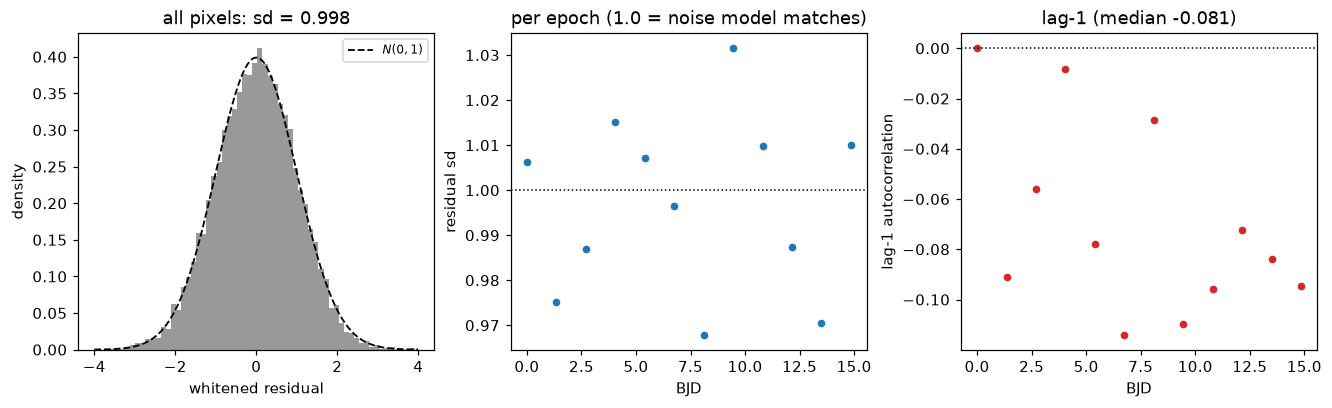

In [5]:
fig, _ = ab.plot_residual_zscores(
    dis.model.problem_at(fit.theta), fit.marginal().d_hat, bjd=dataset.bjd
)
fig.set_layout_engine("constrained")

## The posterior over the orbit

The component spectra are marginalized analytically, so NUTS samples only the orbital
sites. `fit.sample()` freezes the smoothness hyperparameters at their ML-II values, a
plug-in approximation that the summary records, and uses the Laplace covariance at the
MAP as the mass matrix, so warmup only tunes the step size. Two chains run sequentially
on a CPU.

In [6]:
t0 = time.perf_counter()
post = fit.sample(seed=0)
print(f"[{time.perf_counter() - t0:.1f} s]\n")
print(post.summary())

[601.4 s]

NUTS posterior: 1000 draws over 7 sites
  divergences: 0

  period    6.000060 +/- 0.001153
  t_conj    0.625461 +/- 0.002296
  K(primary)    41.986 +/- 0.053 km/s   95% [41.881, 42.090]
  K(secondary)    62.977 +/- 0.091 km/s   95% [62.804, 63.153]

  Smoothness was fixed at its ML-II values, so these intervals do not include
  smoothness uncertainty (a plug-in approximation, not a marginalization).

Assumed, not measured:
  light fractions    primary=0.62  secondary=0.38
      only l_i * d_i is observable, so every recovered depth scales as 1/l_i.
  smoothness starts  primary=300  secondary=300
      ML-II fits these, but which basin it finds depends on where tau starts.


## The posterior orbit curve

albireo measures no per-epoch radial velocity: the orbit is inferred from the spectra
directly, so the figure shows the posterior curve rather than a fit through RV points.
The open circles are the injected component velocities at the observed epochs, which the
draws thread. The ticks along the bottom mark the phase coverage of the epochs, which
determines how well the orbit is constrained.

Text(0.5, 1.0, 'posterior orbit draws; no per-epoch RV was ever measured')

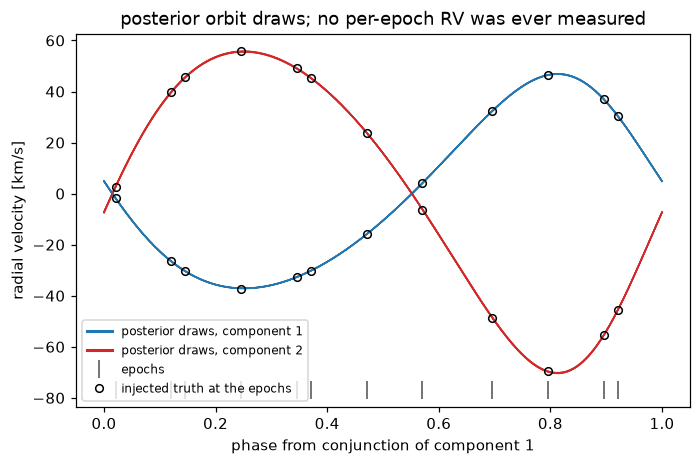

In [7]:
samples = post.samples
fig, ax = ab.plot_rv_curve(samples, dataset.bjd)

period = float(np.mean(np.asarray(samples["period"])))
t_conj = float(np.mean(np.asarray(samples["t_conj"])))
phase = ((dataset.bjd - t_conj) / period) % 1.0
for i in range(2):
    ax.plot(
        phase,
        truth["velocities"][i],
        "o",
        ms=5,
        mfc="none",
        mec="k",
        label="injected truth at the epochs" if i == 0 else None,
    )
ax.legend(fontsize=8)
ax.set_title("posterior orbit draws; no per-epoch RV was ever measured")

## The pairwise posterior

The sampled space is low-dimensional because the spectra are integrated out, so the
corner plot is readable by default. Shown here: period, eccentricity and both
semi-amplitudes.

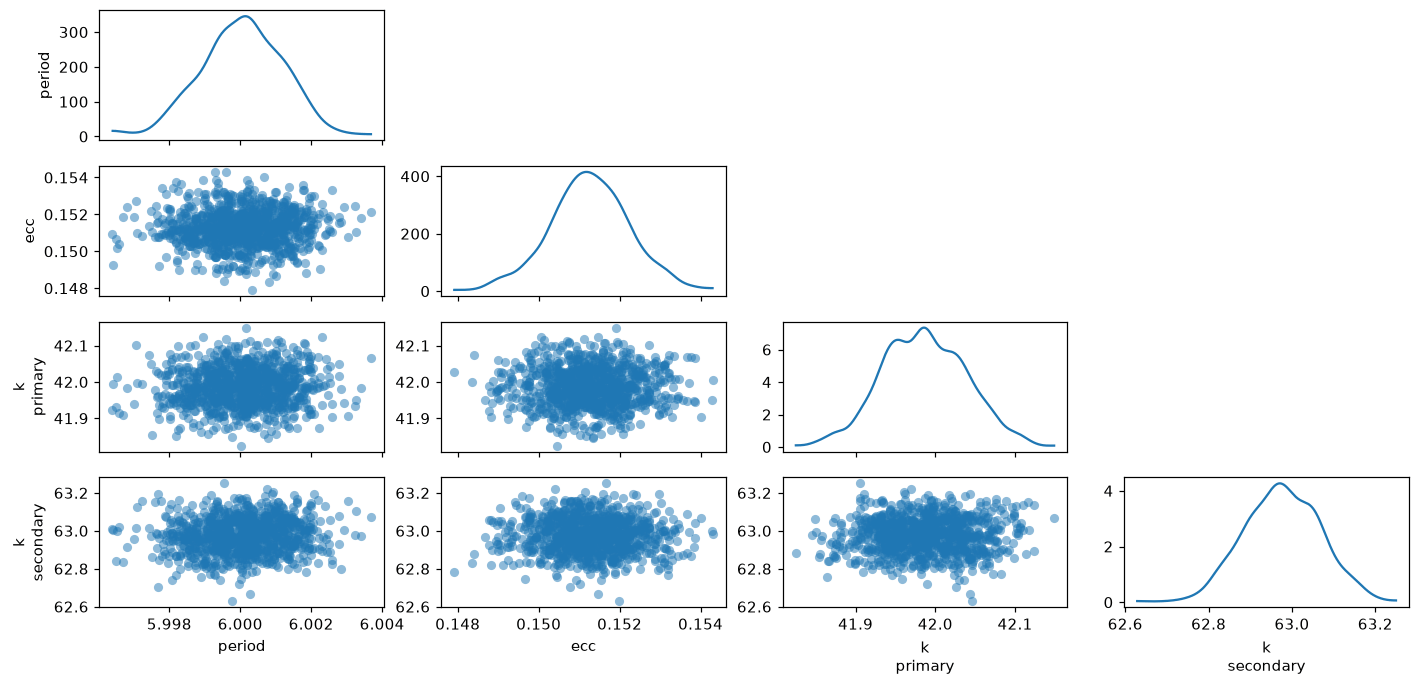

In [8]:
idata = post.to_inference_data()
_ = ab.plot_corner(idata, var_names=["period", "ecc", "k"])

## Spectra from the joint posterior

Each draw takes a posterior orbit and then draws once from the conditional Gaussian over
the spectra, so the scatter carries the orbital and the spectral uncertainty together.
These draws are the object to propagate downstream: equivalent widths measured on them
inherit the `k = 0` exchange between the components, which independent per-pixel error
bars do not represent.

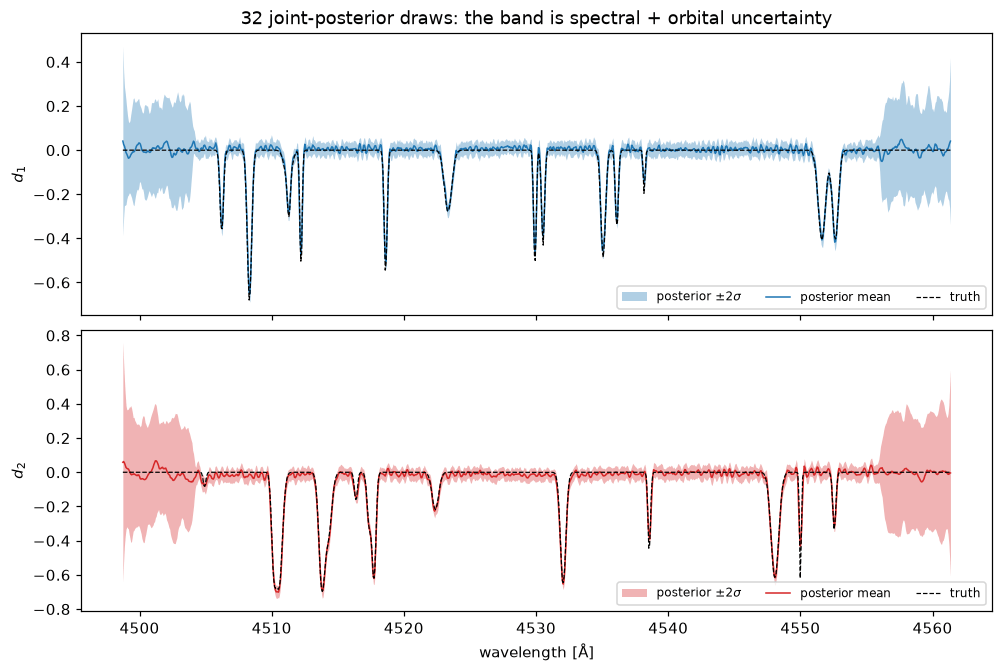

In [9]:
draws = post.spectra(num_draws=32)
fig, axes = ab.plot_spectra(dis.grid, draws, truth=truth_on_model)
axes[0].set_title("32 joint-posterior draws: the band is spectral + orbital uncertainty")
fig.set_layout_engine("constrained")

## Forecast: the effect of six further nights

The posterior covariance of the spectra contains no flux. It depends only on the epochs,
their phases, weights and the prior, so it can be computed for observations that have not
been taken. Planned epochs carry a placeholder flux of exactly 1.0, so a planned dataset
passed to a fit by mistake returns featureless spectra rather than plausible ones. The
forecast below uses the twelve epochs in hand plus six more spread over one period, with
the fitted orbit and the ML-II smoothness from the fit.

Sensitivity forecast: 12 epochs in hand + 6 planned, 2 components (star 1, star 2), 1709 of 2074 component-pixels weighted.
  differential velocity spread (RMS over epochs): 74.7 -> 74.3 km/s
  feature scales where separating the pair costs more than 2x: 33 -> 35% of the sampled range (idealized)
  worst-determined modes, sigma (worst first):
       0.4364    0.1517   0.07974   0.05389   [in hand]
       0.4362     0.127   0.06577    0.0443   [with the 6 planned]
       0.5525    0.5525    0.5524    0.5523   [prior alone]
    the leading mode sits at 1.27x the prior: for two components that is the k=0 exchange, which is degenerate for every design (math.md 5.1). What a design buys is how fast the rest of the ladder falls.
  median band, star 1: 0.01748 -> 0.01669 (prior alone 0.112)
  median band, star 2: 0.02021 -> 0.01923 (prior alone 0.1589)
  constrained spectral degrees of freedom: 556 -> 578 of 1709 covered (2074 on the full grid)
  expected information gain from the 6 planned ep

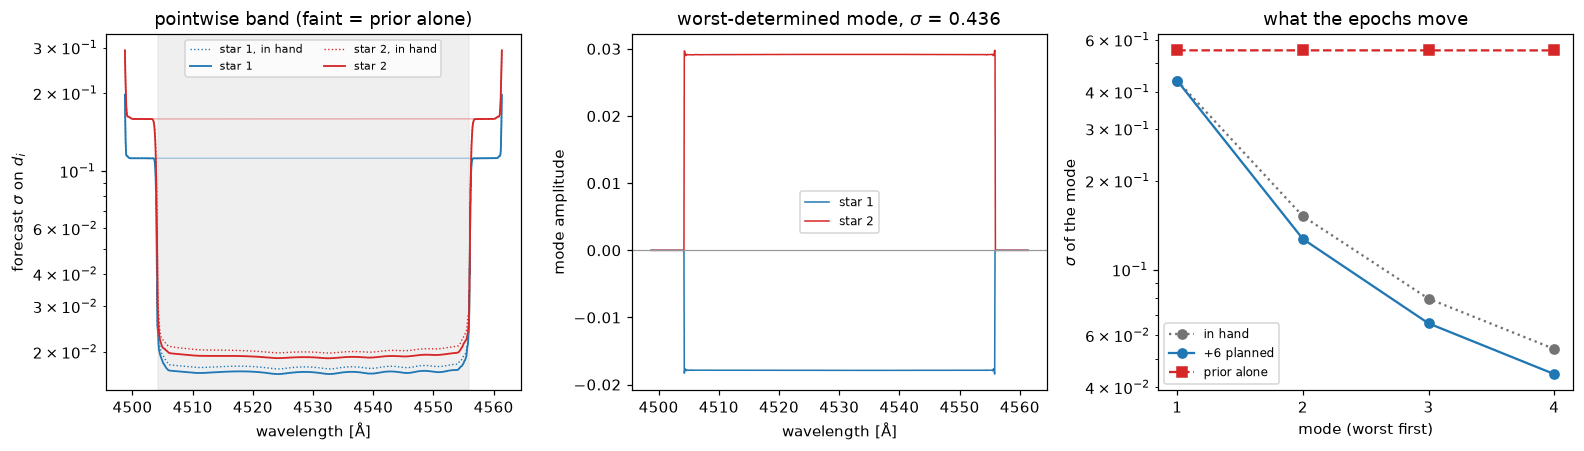

In [10]:
theta_orbit = {site: fit.params[site] for site in ("period", "t_conj", "secosw", "sesinw", "k")}
stars = [fit.star(name) for name in ("primary", "secondary")]
prior = ab.SmoothnessPrior(
    tau=np.array([s["tau"] for s in stars]),
    eta=np.array([s["eta"] for s in stars]),
)

planned_bjd = dataset.bjd.max() + 1.0 + period * np.linspace(0.0, 5.0 / 6.0, 6)
planned = ab.plan_epochs(dataset.epochs[0], planned_bjd)
design = ab.Dataset(dataset.epochs + planned, frame=dataset.frame)

fc = ab.sensitivity_forecast(
    dis.grid,
    design,
    orbit=theta_orbit,
    light_fractions=truth["light_fractions"],
    lsf_sigma_v={"DEMO": 6.5},
    prior=prior,
    baseline=list(range(dataset.n_epochs)),
)
print(fc.summary())
fig, _ = ab.plot_forecast(fc)

## Not shown here

The following are omitted to keep the notebook small; each has a runnable example in the
repository:

- the SB1 faint-companion scan and its calibrated detection limit
  ([`examples/02_k2_scan.py`](https://github.com/tjayasinghe/albireo/blob/main/examples/02_k2_scan.py),
  [`examples/05_detection_limit.py`](https://github.com/tjayasinghe/albireo/blob/main/examples/05_detection_limit.py));
- the nebular component, where unmodelled contamination reaches the masses and not only
  the line depths
  ([`examples/04_nebular.py`](https://github.com/tjayasinghe/albireo/blob/main/examples/04_nebular.py));
- the free per-epoch RV table for systems with no known period
  ([`examples/09_rv_table.py`](https://github.com/tjayasinghe/albireo/blob/main/examples/09_rv_table.py)),
  and real survey data end to end in the BLOeM tutorial;
- the handoff to atmosphere codes with the uncertainty attached
  ([`examples/10_downstream.py`](https://github.com/tjayasinghe/albireo/blob/main/examples/10_downstream.py)).

The measurements behind the statements above are recorded in `docs/benchmarks.md`, and
the design reasoning is in `docs/design.md` and `docs/math.md`.